# Step 1 — Environment Setup

This step prepares the Kaggle environment for QLoRA fine-tuning of **Qwen2.5-VL-3B**. Install all required libraries, verify that the assigned GPU is **T4 or L4** (avoid P100 for 4-bit QLoRA), set random seeds for reproducibility, and print CUDA/VRAM information. A correctly configured environment prevents compatibility and memory issues before loading the model.

In [1]:
# STEP 1 : ENVIRONMENT SETUP
# Install required libraries
!pip install -q -U transformers accelerate peft trl bitsandbytes datasets sentence-transformers qwen-vl-utils

# IMPORT LIBRARIES
import os
import random
import numpy as np
import torch

from transformers import (
    AutoProcessor,
    Qwen2_5_VLForConditionalGeneration,
    BitsAndBytesConfig
)

from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training
)

from datasets import load_dataset

print("Libraries imported successfully.")

# SET RANDOM SEEDS
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print(f"Random seed set to {SEED}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 96.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 46.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.4/596.4 kB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 36.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 55.1 MB/s eta 0:00:00:00:0100:01
Libraries imported successfully.
Random seed set to 42


In [7]:
# CHECK GPU

if torch.cuda.is_available():

    device = torch.device("cuda")

    print(f"GPU Name : {torch.cuda.get_device_name(0)}")

    print(f"CUDA Version : {torch.version.cuda}")

    total_memory = torch.cuda.get_device_properties(0).total_memory / 1024**3

    print(f"GPU Memory : {total_memory:.2f} GB")

else:

    raise RuntimeError("CUDA GPU not available.")

# VERIFY GPU COMPATIBILITY

gpu_name = torch.cuda.get_device_name(0)

if "T4" in gpu_name:
    print("T4 GPU detected ✓")

elif "L4" in gpu_name:
    print("L4 GPU detected ✓")

elif "P100" in gpu_name:
    print("Warning: P100 detected. QLoRA may not work reliably with bitsandbytes.")

else:
    print(f"Using GPU: {gpu_name}")

GPU Name : Tesla T4
CUDA Version : 12.8
GPU Memory : 14.56 GB
T4 GPU detected ✓


In [8]:
# PRINT PYTORCH INFO
print("PyTorch Version :", torch.__version__)
print("CUDA Available :", torch.cuda.is_available())
print("CUDA Version   :", torch.version.cuda)

PyTorch Version : 2.10.0+cu128
CUDA Available : True
CUDA Version   : 12.8


# Step 2 — Load & Verify Dataset

Load the uploaded `train.jsonl`, `validation.jsonl`, and `test.jsonl` files containing the conversation-style VQA dataset. Verify that each JSON entry is valid, image paths exist, and the number of samples matches the expected train/validation/test split (**1386 / 315 / 315**). Finally, visualize a few samples with their conversations to confirm the dataset has been uploaded correctly before training.

Dataset sizes are correct.
All image paths are valid.


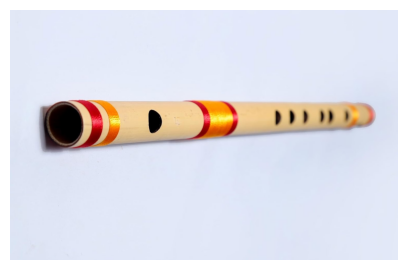

Question:
During which festival is this instrument played?

Answer:
It is played during Rongali Bihu which is the spring festival of Assam.


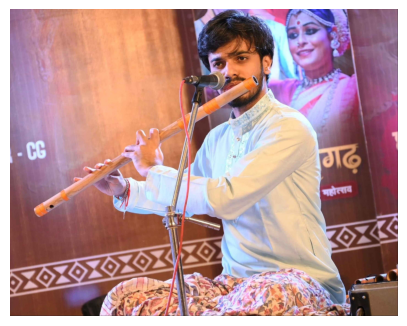

Question:
What is the method of playing this instrument?

Answer:
This instrument is played by blowing air across the blow hole and covering finger holes.


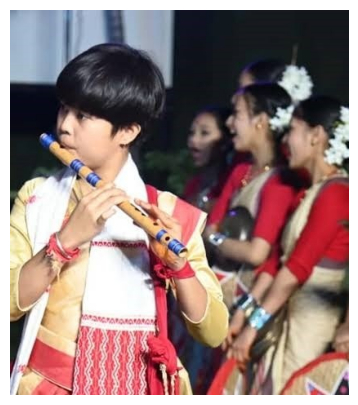

Question:
Where did this instrument originate?

Answer:
It originated in the rural communities of Assam.


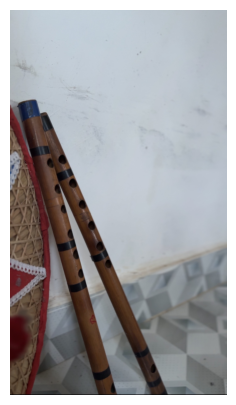

Question:
What material is this instrument made of?

Answer:
This instrument is made of bamboo.


In [9]:
#Import Libraries
import json
import os
from PIL import Image
import matplotlib.pyplot as plt

#Dataset Paths
DATASET_ROOT = "/kaggle/input/datasets/bbeastboy/assamese-instrument-vlm-datasetqwen2-5-vl-3b/kaggle_dataset32"

TRAIN_JSON = os.path.join(DATASET_ROOT, "train.jsonl")
VAL_JSON = os.path.join(DATASET_ROOT, "validation.jsonl")
TEST_JSON = os.path.join(DATASET_ROOT, "test.jsonl")

IMAGE_ROOT = os.path.join(DATASET_ROOT, "dataset_32images")

#Load JSONL
def load_jsonl(file_path):
    data = []
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            data.append(json.loads(line))
    return data

train_data = load_jsonl(TRAIN_JSON)
val_data = load_jsonl(VAL_JSON)
test_data = load_jsonl(TEST_JSON)

#Verify Sample Counts
assert len(train_data) == 1386
assert len(val_data) == 315
assert len(test_data) == 315

print("Dataset sizes are correct.")

#Verify Image Paths
def verify_images(dataset):

    missing = []

    for sample in dataset:

        image_path = sample["messages"][1]["content"][0]["image"]
        full_path = os.path.join(DATASET_ROOT, image_path)

        if not os.path.exists(full_path):
            missing.append(full_path)

    return missing

missing = (
    verify_images(train_data) +
    verify_images(val_data) +
    verify_images(test_data)
)

assert len(missing) == 0

print("All image paths are valid.")

#Display Sample Conversations
def show_sample(dataset, index):

    sample = dataset[index]

    image_path = sample["messages"][1]["content"][0]["image"]
    question = sample["messages"][1]["content"][1]["text"]
    answer = sample["messages"][2]["content"][0]["text"]

    image = Image.open(os.path.join(DATASET_ROOT, image_path))

    plt.figure(figsize=(5,5))
    plt.imshow(image)
    plt.axis("off")
    plt.show()

    print("Question:")
    print(question)

    print("\nAnswer:")
    print(answer)

#Visualize Random Samples
show_sample(train_data,0)
show_sample(train_data,150)
show_sample(val_data,10)
show_sample(test_data,20)

# Step 3 — Load Qwen Processor

Load the `AutoProcessor` for **Qwen2.5-VL-3B**, which combines the tokenizer and image processor into a single interface. It automatically formats conversations using the Qwen chat template, tokenizes text, preprocesses images with dynamic resolution, and prepares multimodal inputs for the model. No manual image resizing or text formatting is required.

In [10]:
# Import AutoProcessor
from transformers import AutoProcessor

# Specify the pretrained Qwen2.5-VL model
MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

# Load the processor
processor=AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    min_pixels=224*28*28,
    max_pixels=384*28*28
)

# Display basic processor information
print(f"Model: {MODEL_ID}")
print(f"Processor Loaded: {type(processor).__name__}")

# Check tokenizer vocabulary size
print(f"Vocabulary Size: {processor.tokenizer.vocab_size:,}")

# Display special tokens
print("Special Tokens:")
print(processor.tokenizer.special_tokens_map)

# Verify processor components
print(f"Tokenizer: {type(processor.tokenizer).__name__}")
print(f"Image Processor: {type(processor.image_processor).__name__}")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Model: Qwen/Qwen2.5-VL-3B-Instruct
Processor Loaded: Qwen2_5_VLProcessor
Vocabulary Size: 151,643
Special Tokens:
{'eos_token': '<|im_end|>', 'pad_token': '<|endoftext|>'}
Tokenizer: Qwen2Tokenizer
Image Processor: Qwen2VLImageProcessor


# Step 4 — Load Qwen2.5-VL-3B (QLoRA)

Load the pretrained **Qwen2.5-VL-3B-Instruct** model using **4-bit NF4 quantization** through BitsAndBytes to reduce GPU memory usage. Configure FP16 as the computation data type and place the model on a single GPU (`device_map={"":0}`). Finally, verify that the model loads successfully and inspect GPU memory usage before proceeding with QLoRA preparation.

In [11]:
# Import required libraries
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig

# Specify model checkpoint
MODEL_ID = "Qwen/Qwen2.5-VL-3B-Instruct"

# Configure 4-bit quantization
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load Qwen2.5-VL model in 4-bit
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"":0},
    trust_remote_code=True
)

# Switch model to evaluation mode
model.eval()

# Print model information
print(f"Model Loaded: {MODEL_ID}")
print(f"Model Device: {next(model.parameters()).device}")
print(f"Model Class: {type(model).__name__}")

# Display GPU memory usage
allocated = torch.cuda.memory_allocated()/1024**3
reserved = torch.cuda.memory_reserved()/1024**3

print(f"GPU Memory Allocated : {allocated:.2f} GB")
print(f"GPU Memory Reserved  : {reserved:.2f} GB")

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

Model Loaded: Qwen/Qwen2.5-VL-3B-Instruct
Model Device: cuda:0
Model Class: Qwen2_5_VLForConditionalGeneration
GPU Memory Allocated : 2.25 GB
GPU Memory Reserved  : 2.35 GB


# Step 5 — Build Dataset Class

Create a custom PyTorch `Dataset` to load the JSONL conversations generated earlier. For each sample, load the corresponding image, reconstruct the **system → user → assistant** conversation, and extract visual inputs using `process_vision_info`. The dataset should return the raw conversation, image information, and ground-truth response, while leaving tokenization and batching to the processor and data collator in the next steps.

In [12]:
# Import required libraries
import os
import json
from PIL import Image
from torch.utils.data import Dataset
from qwen_vl_utils import process_vision_info

# Custom Dataset for Qwen2.5-VL
class QwenVQADataset(Dataset):

    # Initialize dataset
    def __init__(self,jsonl_path,dataset_root):
        self.dataset_root=dataset_root
        self.samples=[]

        with open(jsonl_path,"r",encoding="utf-8") as f:
            for line in f:
                self.samples.append(json.loads(line))

    # Return total number of samples
    def __len__(self):
        return len(self.samples)

    # Return one sample
    def __getitem__(self,idx):

        sample=self.samples[idx]

        messages=sample["messages"]

        image_path=os.path.join(
            self.dataset_root,
            messages[1]["content"][0]["image"]
        )

        image=Image.open(image_path).convert("RGB")

        # Update image path inside the conversation
        messages[1]["content"][0]["image"]=image_path

        image_inputs,video_inputs=process_vision_info(messages)

        return{
            "messages":messages,
            "image":image,
            "image_inputs":image_inputs,
            "video_inputs":video_inputs
        }

# Create dataset objects
train_dataset=QwenVQADataset(TRAIN_JSON,DATASET_ROOT)
val_dataset=QwenVQADataset(VAL_JSON,DATASET_ROOT)
test_dataset=QwenVQADataset(TEST_JSON,DATASET_ROOT)

# Verify dataset
print(f"Train Samples : {len(train_dataset)}")
print(f"Validation Samples : {len(val_dataset)}")
print(f"Test Samples : {len(test_dataset)}")

sample=train_dataset[0]

print(f"Loaded Image Size : {sample['image'].size}")
print(f"Number of Messages : {len(sample['messages'])}")
print(f"Vision Inputs Created : {sample['image_inputs'] is not None}")

Train Samples : 1386
Validation Samples : 315
Test Samples : 315
Loaded Image Size : (1500, 969)
Number of Messages : 3
Vision Inputs Created : True


# Step 6 — Build Data Collator

Implement a custom data collator that converts raw conversations into model-ready tensors during training. The collator applies the Qwen chat template, tokenizes text with the processor, preprocesses images, dynamically handles variable-length visual tokens, pads sequences to the same length, and creates training labels by masking user and padding tokens so that only the assistant's response contributes to the loss.

In [13]:
# Import required library
import torch

# Custom data collator for Qwen2.5-VL
class QwenDataCollator:

    # Initialize collator
    def __init__(self,processor):
        self.processor=processor

    # Build one training batch
    def __call__(self,batch):

        # Extract conversations
        conversations=[sample["messages"] for sample in batch]

        # Extract images
        images=[sample["image"] for sample in batch]

        # Apply Qwen chat template
        texts=[
            self.processor.apply_chat_template(
                conversation,
                tokenize=False,
                add_generation_prompt=False
            )
            for conversation in conversations
        ]

        # Tokenize text and images
        model_inputs=self.processor(
            text=texts,
            images=images,
            padding=True,
            return_tensors="pt"
        )

        # Create labels from input ids
        labels=model_inputs["input_ids"].clone()

        # Ignore padding tokens
        labels[labels==self.processor.tokenizer.pad_token_id]=-100

        # Ignore image tokens
        if hasattr(self.processor,"image_token_id"):
            labels[labels==self.processor.image_token_id]=-100

        # Return training batch
        model_inputs["labels"]=labels

        return model_inputs

# Create collator
data_collator=QwenDataCollator(processor)

# Verify collator
batch=data_collator([
    train_dataset[0],
    train_dataset[1]
])

print(batch.keys())

print(batch["input_ids"].shape)
print(batch["attention_mask"].shape)
print(batch["pixel_values"].shape)
print(batch["labels"].shape)

KeysView({'input_ids': tensor([[151644,   8948,    198,   2610,    525,    458,   6203,    389,   2688,
            971,     68,  17795,  23316,     13, 151645,    198, 151644,    872,
            198, 151652, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
     

In [14]:
batch=data_collator([train_dataset[0]])

print(batch["input_ids"].shape)
print(batch["pixel_values"].shape)

torch.Size([1, 414])
torch.Size([1440, 1176])


# Step 7 — Configure QLoRA

Prepare the quantized Qwen2.5-VL model for low-bit training using `prepare_model_for_kbit_training()`, then attach LoRA adapters with PEFT. Freeze the vision encoder so only the language model is adapted, target the attention projection layers (`q_proj` and `v_proj`), and verify the number of trainable parameters. This ensures that only lightweight LoRA adapters are updated during fine-tuning.

In [15]:
# Import PEFT utilities
from peft import LoraConfig,get_peft_model,prepare_model_for_kbit_training

# Prepare model for k-bit training
model=prepare_model_for_kbit_training(model)

# Freeze all vision encoder parameters
for name,param in model.named_parameters():
    if name.startswith("model.visual."):
        param.requires_grad=False

vision_trainable=sum(
    p.numel()
    for n,p in model.named_parameters()
    if n.startswith("model.visual.") and p.requires_grad
)

print(f"Vision trainable parameters: {vision_trainable}")

# Configure LoRA
lora_config=LoraConfig(
    r=8,
    lora_alpha=16,
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules=[
        "q_proj",
        "v_proj"
    ]
)

# Attach LoRA adapters
model=get_peft_model(model,lora_config)

# Print trainable parameter statistics
model.print_trainable_parameters()

# Verify vision encoder is frozen
vision_trainable=sum(
    p.numel()
    for n,p in model.named_parameters()
    if n.startswith("model.visual.") and p.requires_grad
)

language_trainable=sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(f"Vision Trainable Parameters : {vision_trainable:,}")
print(f"Total Trainable Parameters : {language_trainable:,}")

Vision trainable parameters: 0
trainable params: 1,843,200 || all params: 3,756,466,176 || trainable%: 0.0491
Vision Trainable Parameters : 0
Total Trainable Parameters : 1,843,200


# Step 8 — Sanity Check

Before starting full fine-tuning, perform a single forward and backward pass using one mini-batch from the training set. This verifies that the dataset, processor, data collator, QLoRA model, and optimizer are correctly connected. Confirm that the loss is finite, gradients are computed, GPU memory remains stable, and no runtime errors or out-of-memory issues occur before launching long training.

In [16]:
# Import required libraries
from torch.utils.data import DataLoader
import torch

# Create training dataloader
train_loader=DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=True,
    collate_fn=data_collator
)

# Create optimizer
optimizer=torch.optim.AdamW(
    model.parameters(),
    lr=2e-4
)

# Enable training mode
model.train()
model.gradient_checkpointing_enable()

# Get one training batch
batch=next(iter(train_loader))

# Move tensors to GPU
batch={k:v.to(model.device) if isinstance(v,torch.Tensor) else v for k,v in batch.items()}

# Clear previous gradients
optimizer.zero_grad()

# Forward pass
outputs=model(**batch)

# Compute loss
loss=outputs.loss

# Verify loss
assert torch.isfinite(loss),"Loss is NaN or Inf."

print(f"Initial Loss : {loss.item():.4f}")

# Backward pass
loss.backward()

# Verify gradients
grad_found=False

for name,param in model.named_parameters():
    if param.requires_grad and param.grad is not None:
        grad_found=True
        break

assert grad_found,"No gradients were computed."

print("Backward pass successful.")

# Optimizer step
optimizer.step()

# Clear gradients
optimizer.zero_grad()

# Display GPU memory usage
allocated=torch.cuda.memory_allocated()/1024**3
reserved=torch.cuda.memory_reserved()/1024**3

print(f"GPU Memory Allocated : {allocated:.2f} GB")
print(f"GPU Memory Reserved : {reserved:.2f} GB")

print("Sanity check completed successfully.")

[transformers] `use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


Initial Loss : 6.0331
Backward pass successful.
GPU Memory Allocated : 3.06 GB
GPU Memory Reserved : 3.89 GB
Sanity check completed successfully.


# Step 9 — Fine-tune

Configure the Hugging Face `Trainer` using `TrainingArguments` optimized for QLoRA fine-tuning. Enable gradient accumulation, gradient checkpointing, FP16 mixed precision, cosine learning-rate scheduling, checkpoint saving, and early stopping. Evaluate **only on the validation set** after each epoch, automatically load the best checkpoint based on validation loss, and never use the test set during training or model selection.

In [18]:
# Import required libraries
from transformers import TrainingArguments,Trainer,EarlyStoppingCallback

print("train args start")

# Configure training arguments
training_args=TrainingArguments(
    output_dir="./qwen2.5vl_lora_output",
    num_train_epochs=5,
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,
    learning_rate=2e-4,
    lr_scheduler_type="cosine",
    warmup_steps=50,
    weight_decay=0.01,
    fp16=True,
    gradient_checkpointing=True,
    do_train=True,
    do_eval=True,
    use_cache=False,
    logging_strategy="steps",
    logging_steps=10,
    eval_strategy="epoch",
    save_strategy="epoch",
    save_total_limit=2,
    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,
    report_to="none",
    remove_unused_columns=False,
    dataloader_num_workers=2,
    dataloader_pin_memory=True,
    max_grad_norm=1.0
)

model.config.use_cache=False
model.enable_input_require_grads()

print("train args end")

train args start
train args end


In [19]:
print("trainer start")
# Create trainer
trainer=Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    data_collator=data_collator,
    processing_class=processor,
    callbacks=[
        EarlyStoppingCallback(
            early_stopping_patience=2
        )
    ]
)

print(len(train_dataset),len(val_dataset))
batch=data_collator([train_dataset[0]])
print(batch.keys())

print("trainer end")

trainer start
1386 315
KeysView({'input_ids': tensor([[151644,   8948,    198,   2610,    525,    458,   6203,    389,   2688,
            971,     68,  17795,  23316,     13, 151645,    198, 151644,    872,
            198, 151652, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655, 151655,
         151655, 151655, 151655, 151655, 151655, 151655, 151655

In [20]:
print("training start")
# Start fine-tuning
trainer.train()
print("training end")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 151645, 'bos_token_id': None, 'pad_token_id': 151643}.


training start


Epoch,Training Loss,Validation Loss
1,1.539243,1.136842
2,0.661225,0.819064
3,0.679032,0.846797
4,0.756808,0.872887


training end


In [21]:
print("eval best checkpoint start")

# Evaluate best checkpoint on validation set
validation_metrics=trainer.evaluate()

# Display validation metrics
print(validation_metrics)

print("eval best checkpoint end")

eval best checkpoint start


Training Loss,Validation Loss,Epoch
0.756808,0.819064,4


{'eval_loss': 0.8190642595291138}
eval best checkpoint end


# Step 10 — Save Model

After fine-tuning, save the trained **LoRA adapters**, processor, tokenizer, training arguments, and training logs. These files are required to reload the fine-tuned model for inference without retraining. Since Kaggle sessions are temporary, immediately save the artifacts to the Kaggle Output directory and optionally upload them to Hugging Face Hub or GitHub for permanent storage.

In [22]:
# Import required libraries
import os
import json
import torch
import shutil
from transformers import TrainerState

# Create output directory
SAVE_DIR="/kaggle/working/qwen2.5vl_lora"
os.makedirs(SAVE_DIR,exist_ok=True)

# Save LoRA adapter
model.save_pretrained(os.path.join(SAVE_DIR,"adapter"))

# Save processor
processor.save_pretrained(os.path.join(SAVE_DIR,"processor"))

# Save tokenizer
processor.tokenizer.save_pretrained(os.path.join(SAVE_DIR,"tokenizer"))

# Save training arguments
torch.save(
    trainer.args,
    os.path.join(SAVE_DIR, "training_args.pt")
)

# Save trainer state
trainer.state.save_to_json(os.path.join(SAVE_DIR,"trainer_state.json"))

# Save evaluation metrics
validation_metrics=trainer.evaluate()

with open(os.path.join(SAVE_DIR,"validation_metrics.json"),"w") as f:
    json.dump(validation_metrics,f,indent=4)

# Save training log history
with open(os.path.join(SAVE_DIR,"log_history.json"),"w") as f:
    json.dump(trainer.state.log_history,f,indent=4)

# Create compressed backup
shutil.make_archive(
    base_name="/kaggle/working/qwen2.5vl_lora_backup",
    format="zip",
    root_dir=SAVE_DIR
)

print(f"Model saved to: {SAVE_DIR}")
print("Backup ZIP created successfully.")

Training Loss,Validation Loss,Epoch
0.756808,0.819064,4


Model saved to: /kaggle/working/qwen2.5vl_lora
Backup ZIP created successfully.


# Step 11 — Inference

Reload the original **Qwen2.5-VL-3B-Instruct** model and attach the fine-tuned LoRA adapters to reconstruct the complete model. Run inference on the **test dataset** using the same chat template and processor used during training to ensure consistency. Generate answers for every test sample and save the image path, question, prediction, and ground-truth answer into a JSON file for evaluation.

In [28]:
# Import required libraries
import os
import copy
import json
import torch
from tqdm import tqdm
from peft import PeftModel
import pandas as pd
from transformers import AutoProcessor,Qwen2_5_VLForConditionalGeneration,BitsAndBytesConfig
from qwen_vl_utils import process_vision_info

# Define model and adapter paths
MODEL_ID="Qwen/Qwen2.5-VL-3B-Instruct"
ADAPTER_PATH="/kaggle/working/qwen2.5vl_lora/adapter"
TEST_JSON="/kaggle/input/datasets/bbeastboy/assamese-instrument-vlm-datasetqwen2-5-vl-3b/kaggle_dataset32/test.jsonl"
OUTPUT_JSON="/kaggle/working/test_predictions.json"
FINAL_VQA_CSV="/kaggle/input/datasets/bbeastboy/assamese-instrument-vlm-datasetqwen2-5-vl-3b/kaggle_dataset32/final_vqa.csv"
IMAGE_ROOT="/kaggle/input/datasets/bbeastboy/assamese-instrument-vlm-datasetqwen2-5-vl-3b/kaggle_dataset32"

# Configure 4-bit inference
bnb_config=BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True
)

# Load processor
processor=AutoProcessor.from_pretrained(
    MODEL_ID,
    trust_remote_code=True,
    min_pixels=224*28*28,
    max_pixels=384*28*28
)

# Load base model
base_model=Qwen2_5_VLForConditionalGeneration.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    torch_dtype=torch.float16,
    device_map={"":0},
    trust_remote_code=True
)

# Attach LoRA adapter
model=PeftModel.from_pretrained(
    base_model,
    ADAPTER_PATH
)

# Switch to evaluation mode
model.eval()

# Load test samples
test_samples=[]

with open(TEST_JSON,"r",encoding="utf-8") as f:
    for line in f:
        test_samples.append(json.loads(line))

# Load final_vqa.csv metadata
metadata_df=pd.read_csv(FINAL_VQA_CSV)

# Keep only test rows
metadata_df=metadata_df[metadata_df["split"]=="test"]

# Build lookup table
metadata_lookup={}

for _,row in metadata_df.iterrows():

    key=(
        row["image_name"],
        row["question"]
    )

    metadata_lookup[key]={
        "instrument":row["instrument"],
        "question_id":row["question_id"],
        "concept":row["concept"]
    }

predictions=[]

# Run inference
with torch.inference_mode():
    
    for sample in tqdm(test_samples):

        # Create a copy so the original JSON is unchanged
        messages=copy.deepcopy(sample["messages"])

        # Convert relative image path to absolute Kaggle path
        messages[1]["content"][0]["image"]=os.path.join(
            IMAGE_ROOT,
            messages[1]["content"][0]["image"]
        )

        image_inputs,video_inputs=process_vision_info(messages)

        prompt=processor.apply_chat_template(
            messages,
            tokenize=False,
            add_generation_prompt=True
        )

        inputs=processor(
            text=[prompt],
            images=image_inputs,
            videos=video_inputs,
            padding=True,
            return_tensors="pt"
        ).to(model.device)

        generated_ids=model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False
        )

        generated_ids=generated_ids[:,inputs.input_ids.shape[1]:]

        prediction=processor.batch_decode(
            generated_ids,
            skip_special_tokens=True,
            clean_up_tokenization_spaces=True
        )[0]

        # Extract sample information
        image_path=messages[1]["content"][0]["image"]

        image_name=os.path.basename(image_path)

        question=messages[1]["content"][1]["text"]

        ground_truth=messages[2]["content"][0]["text"]

        # Get metadata from final_vqa.csv
        metadata=metadata_lookup[(image_name,question)]

        predictions.append({
            "image":image_path,
            "instrument":metadata["instrument"],
            "question_id":metadata["question_id"],
            "concept":metadata["concept"],
            "question":question,
            "ground_truth":ground_truth,
            "prediction":prediction.strip()
        })

# Save predictions
with open(OUTPUT_JSON,"w",encoding="utf-8") as f:
    json.dump(predictions,f,indent=4,ensure_ascii=False)

print(f"Saved {len(predictions)} predictions to {OUTPUT_JSON}")

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

100%|██████████| 315/315 [17:08<00:00,  3.27s/it]

Saved 315 predictions to /kaggle/working/test_predictions.json


# Step 12 — LAVE Evaluation

Evaluate the fine-tuned model using **LAVE (LLM-as-a-Verifier Evaluation)** with **Gemini 2.5 Flash** as the judge. For each test sample, compare the generated answer against the reference answer while considering the question context, then assign a score between **0.0** (incorrect) and **1.0** (perfectly correct). Finally, compute the overall average LAVE score and analyze performance separately for each **instrument** and **question concept** using the metadata saved during inference.

In [40]:
# Import required libraries
import os
import json
import time
import pandas as pd
import google.generativeai as genai
from tqdm import tqdm

from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
secret_value_0 = user_secrets.get_secret("GOOGLE_API_KEY")


# Configure Gemini API
genai.configure(api_key=secret_value_0)
judge_model=genai.GenerativeModel("gemini-3.1-flash-lite")

# Define file paths
PREDICTIONS_JSON="/kaggle/working/test_predictions.json"
OUTPUT_JSON="/kaggle/working/lave_results.json"

# Load prediction file
with open(PREDICTIONS_JSON,"r",encoding="utf-8") as f:
    predictions=json.load(f)

# Store evaluation results
results=[]

# Evaluate every prediction
for sample in tqdm(predictions):

    prompt=f"""
You are an expert evaluator for Visual Question Answering.

Compare the predicted answer with the reference answer based on factual correctness, semantic similarity, and completeness.

Question:
{sample['question']}

Ground Truth:
{sample['ground_truth']}

Predicted Answer:
{sample['prediction']}

Return ONLY valid JSON in this exact format:

{{
  "score": 0.95,
  "reason": "Short explanation."
}}

Rules:
- score must be between 0.0 and 1.0
- 1.0 = perfectly correct
- 0.8 = mostly correct
- 0.5 = partially correct
- 0.2 = mostly incorrect
- 0.0 = completely incorrect

Do not output anything except the JSON object.
"""

    while True:

        try:

            response=judge_model.generate_content(prompt)

            text=response.text.strip()

            if text.startswith("```"):
                text=text.replace("```json","").replace("```","").strip()

            result=json.loads(text)

            score=float(result["score"])

            score=max(0.0,min(1.0,score))

            reason=result["reason"]

            break

        except Exception as e:

            if "429" in str(e):

                print("Rate limit reached. Waiting 35 seconds...")

                time.sleep(35)

                continue

            score=None

            reason=str(e)

            break

    if score is None:
        continue

    results.append({
        "instrument":sample["instrument"],
        "question_id":sample["question_id"],
        "concept":sample["concept"],
        "question":sample["question"],
        "ground_truth":sample["ground_truth"],
        "prediction":sample["prediction"],
        "lave_score":score,
        "reason":reason
    })

    time.sleep(5)

# Save detailed LAVE results
with open(OUTPUT_JSON,"w",encoding="utf-8") as f:
    json.dump(results,f,indent=4,ensure_ascii=False)

# Create dataframe
df=pd.DataFrame(results)

# Compute overall LAVE
overall_lave=df["lave_score"].mean()

# Compute instrument-wise LAVE
instrument_lave=df.groupby("instrument")["lave_score"].mean().sort_values(ascending=False)

# Compute concept-wise LAVE
concept_lave=df.groupby("concept")["lave_score"].mean().sort_values(ascending=False)

# Display results
print(f"Overall LAVE Score : {overall_lave:.4f}")

print("\nInstrument-wise LAVE")
print(instrument_lave)

print("\nConcept-wise LAVE")
print(concept_lave)

100%|██████████| 315/315 [30:10<00:00,  5.75s/it]

Overall LAVE Score : 0.7675

Instrument-wise LAVE
instrument
pepa         0.840000
bihu_dhol    0.833333
gogona       0.792222
khutitaal    0.735556
bahi         0.728889
toka         0.728889
xutuli       0.713333
Name: lave_score, dtype: float64

Concept-wise LAVE
concept
material              0.985714
sound                 0.922857
playing_method        0.874286
instrument_type       0.822857
parts                 0.801429
description           0.775714
traditional_player    0.758571
festival              0.588571
origin                0.377143
Name: lave_score, dtype: float64


# Step 13 — Cosine Similarity Evaluation

Evaluate semantic similarity between the generated and reference answers using a pretrained **Sentence-Transformer** model. Convert both answers into sentence embeddings, compute cosine similarity for each test sample, and report the overall average score. Additionally, calculate average cosine similarity for each **instrument** and **question concept** to complement the LAVE evaluation with an embedding-based metric.

In [41]:
# Import required libraries
import json
import pandas as pd
from sentence_transformers import SentenceTransformer
from sentence_transformers.util import cos_sim
from tqdm import tqdm

# Define file paths
PREDICTIONS_JSON="/kaggle/working/test_predictions.json"
OUTPUT_JSON="/kaggle/working/cosine_results.json"

# Load prediction file
with open(PREDICTIONS_JSON,"r",encoding="utf-8") as f:
    predictions=json.load(f)

# Load sentence embedding model
embedding_model=SentenceTransformer("all-mpnet-base-v2")

# Prepare text lists
ground_truth_list=[sample["ground_truth"] for sample in predictions]
prediction_list=[sample["prediction"] for sample in predictions]

# Encode all ground truths in batches
gt_embeddings=embedding_model.encode(
    ground_truth_list,
    batch_size=32,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# Encode all predictions in batches
pred_embeddings=embedding_model.encode(
    prediction_list,
    batch_size=32,
    convert_to_tensor=True,
    normalize_embeddings=True,
    show_progress_bar=True
)

# Store cosine similarity results
results=[]

# Compute cosine similarity for every sample
for sample,gt_embedding,pred_embedding in zip(
    predictions,
    gt_embeddings,
    pred_embeddings
):

    cosine_score=cos_sim(
        gt_embedding,
        pred_embedding
    ).item()

    cosine_score=max(0.0,min(1.0,cosine_score))

    results.append({
        "instrument":sample["instrument"],
        "question_id":sample["question_id"],
        "concept":sample["concept"],
        "question":sample["question"],
        "ground_truth":sample["ground_truth"],
        "prediction":sample["prediction"],
        "cosine_similarity":cosine_score
    })

# Save detailed cosine results
with open(OUTPUT_JSON,"w",encoding="utf-8") as f:
    json.dump(results,f,indent=4,ensure_ascii=False)

# Create dataframe
df=pd.DataFrame(results)

df.to_csv(
    "/kaggle/working/cosine_results.csv",
    index=False
)

# Compute overall cosine similarity
overall_cosine=df["cosine_similarity"].mean()

# Compute instrument-wise cosine similarity
instrument_cosine=df.groupby("instrument")["cosine_similarity"].mean().sort_values(ascending=False)

# Compute concept-wise cosine similarity
concept_cosine=df.groupby("concept")["cosine_similarity"].mean().sort_values(ascending=False)

# Display results
print(f"Overall Cosine Similarity : {overall_cosine:.4f}")

print("\nInstrument-wise Cosine Similarity")
print(instrument_cosine)

print("\nConcept-wise Cosine Similarity")
print(concept_cosine)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Batches:   0%|          | 0/10 [00:00<?, ?it/s]

Overall Cosine Similarity : 0.8333

Instrument-wise Cosine Similarity
instrument
pepa         0.867220
gogona       0.846445
bihu_dhol    0.842089
bahi         0.833943
khutitaal    0.833017
xutuli       0.805956
toka         0.804593
Name: cosine_similarity, dtype: float64

Concept-wise Cosine Similarity
concept
material              0.997290
description           0.962342
sound                 0.958191
playing_method        0.940812
traditional_player    0.901195
parts                 0.886641
instrument_type       0.815696
festival              0.667972
origin                0.369768
Name: cosine_similarity, dtype: float64


# Step 14 — Result Analysis & Visualization

Analyze the fine-tuning results using both quantitative metrics and qualitative examples. Visualize the training and validation loss curves, compare **LAVE** and **Cosine Similarity** across instruments and question concepts, and inspect representative best and worst predictions. Finally, compare the fine-tuned Qwen2.5-VL model against the **PaliGemma baseline (Cosine ≈ 0.66, LAVE ≈ 0.13)** to measure the improvement achieved through fine-tuning.

Best Checkpoint : ./qwen2.5vl_lora_output/checkpoint-174
Best Validation Loss : 0.8191


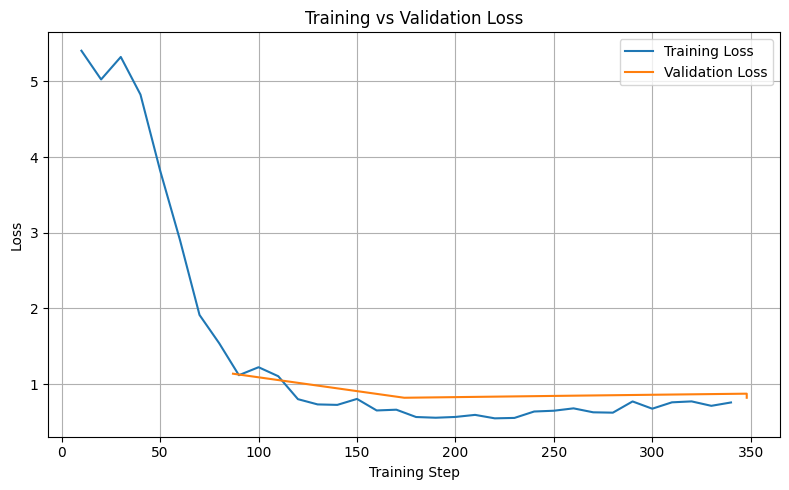

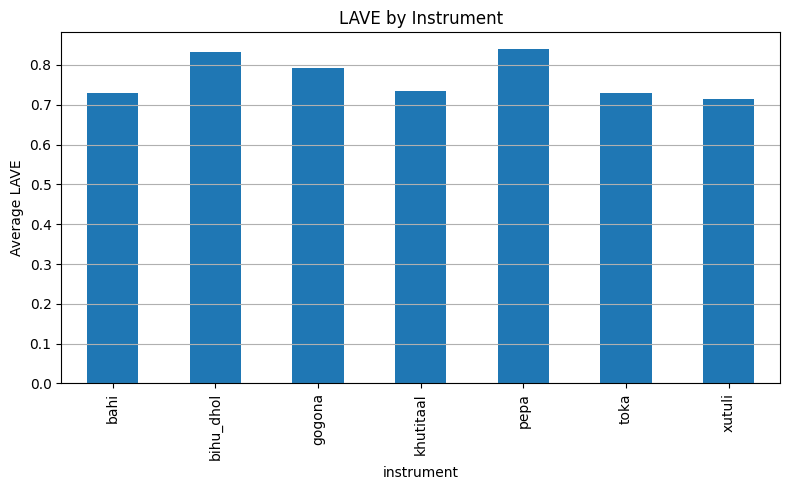

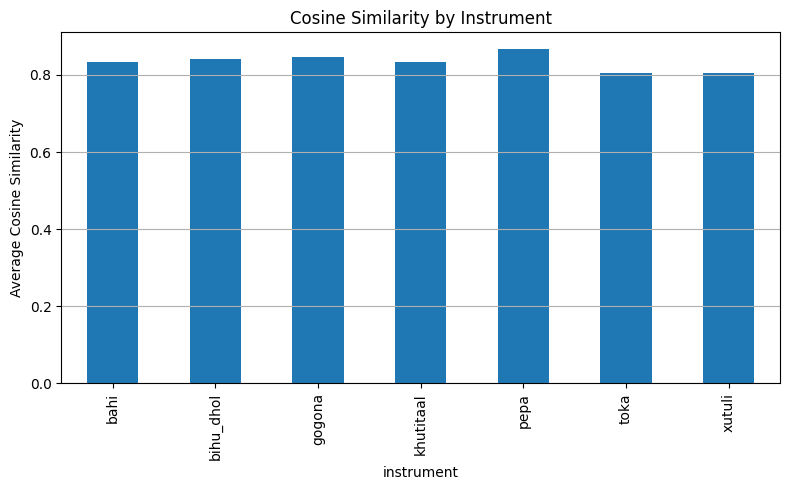

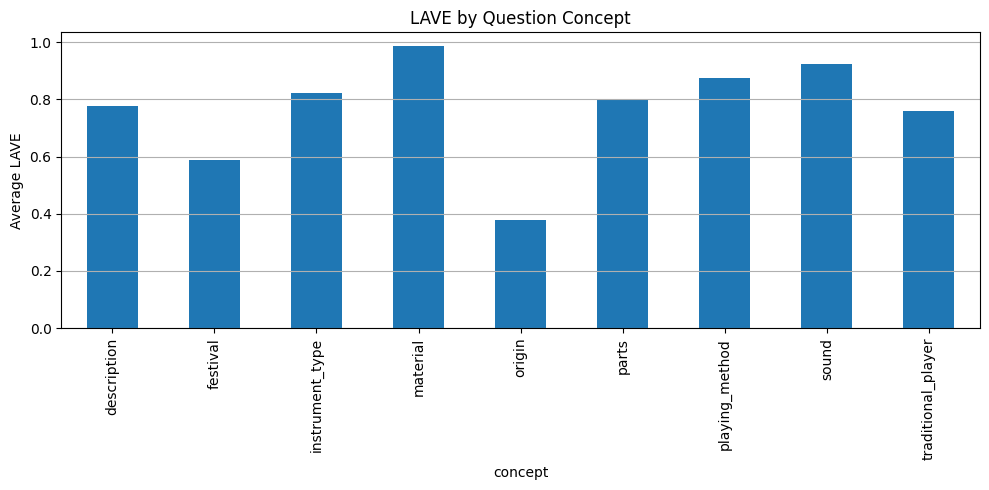

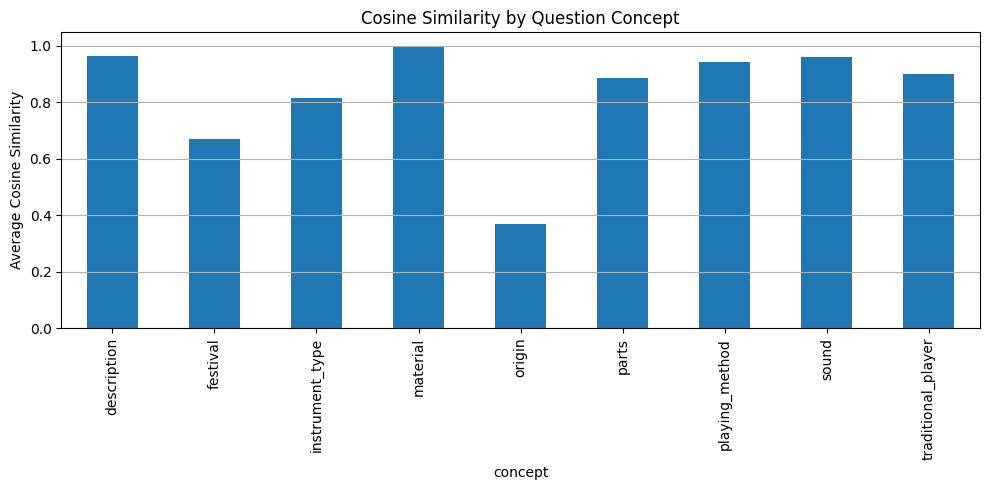

<Figure size 600x500 with 0 Axes>

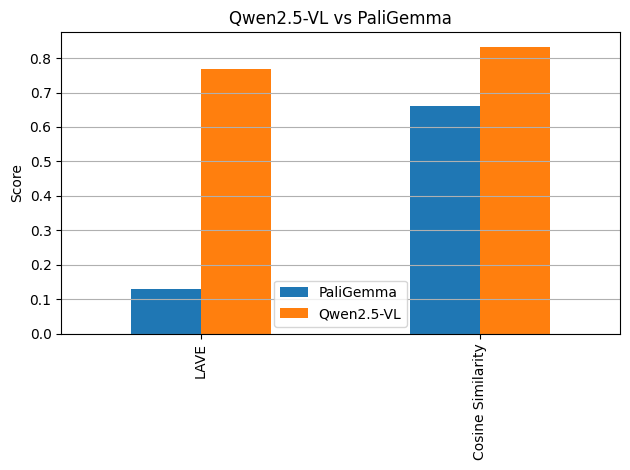

Overall LAVE : 0.7675
Overall Cosine Similarity : 0.8333
LAVE Improvement : 490.35%
Cosine Improvement : 26.26%

Instrument-wise Performance
            lave_score  cosine_similarity
instrument                               
bahi          0.728889           0.833943
bihu_dhol     0.833333           0.842089
gogona        0.792222           0.846445
khutitaal     0.735556           0.833017
pepa          0.840000           0.867220
toka          0.728889           0.804593
xutuli        0.713333           0.805956

Concept-wise Performance
                    lave_score  cosine_similarity
concept                                          
description           0.775714           0.962342
festival              0.588571           0.667972
instrument_type       0.822857           0.815696
material              0.985714           0.997290
origin                0.377143           0.369768
parts                 0.801429           0.886641
playing_method        0.874286           0.940812
sound

In [47]:
# Import required libraries
import json
import pandas as pd
import matplotlib.pyplot as plt

# Define file paths
TRAINER_STATE="/kaggle/working/qwen2.5vl_lora/trainer_state.json"
LAVE_RESULTS="/kaggle/working/lave_results.json"
COSINE_RESULTS="/kaggle/working/cosine_results.json"

# Define PaliGemma baseline
PALIGEMMA_COSINE=0.66
PALIGEMMA_LAVE=0.13

# Load trainer state
with open(TRAINER_STATE,"r",encoding="utf-8") as f:
    trainer_state=json.load(f)

# Load evaluation results
with open(LAVE_RESULTS,"r",encoding="utf-8") as f:
    lave_results=pd.DataFrame(json.load(f))

with open(COSINE_RESULTS,"r",encoding="utf-8") as f:
    cosine_results=pd.DataFrame(json.load(f))

# Extract training and validation loss
train_loss=[]
train_steps=[]

eval_loss=[]
eval_steps=[]

for log in trainer_state["log_history"]:

    if "loss" in log:
        train_steps.append(log["step"])
        train_loss.append(log["loss"])

    if "eval_loss" in log:
        eval_steps.append(log["step"])
        eval_loss.append(log["eval_loss"])

# Compute overall metrics
overall_lave=lave_results["lave_score"].mean()
overall_cosine=cosine_results["cosine_similarity"].mean()

best_checkpoint=trainer_state["best_model_checkpoint"]
best_metric=trainer_state["best_metric"]

print(f"Best Checkpoint : {best_checkpoint}")
print(f"Best Validation Loss : {best_metric:.4f}")

# Merge evaluation results
merged=lave_results.merge(
    cosine_results[
        [
            "instrument",
            "question_id",
            "question",
            "cosine_similarity"
        ]
    ],
    on=[
        "instrument",
        "question_id",
        "question"
    ]
)

# Compute per-instrument metrics
instrument_scores=merged.groupby("instrument")[["lave_score","cosine_similarity"]].mean()

instrument_scores.to_csv(
    "/kaggle/working/instrument_scores.csv"
)

# Compute per-concept metrics
concept_scores=merged.groupby("concept")[["lave_score","cosine_similarity"]].mean()

concept_scores.to_csv(
    "/kaggle/working/concept_scores.csv"
)

# Compute improvement over baseline
lave_improvement=((overall_lave-PALIGEMMA_LAVE)/PALIGEMMA_LAVE)*100
cosine_improvement=((overall_cosine-PALIGEMMA_COSINE)/PALIGEMMA_COSINE)*100

# Select best and worst predictions
best_predictions=merged.sort_values("lave_score",ascending=False).head(5)

worst_predictions=merged.sort_values("lave_score").head(5)

# Plot training and validation loss
plt.figure(figsize=(8,5))
plt.plot(train_steps,train_loss,label="Training Loss")
plt.plot(eval_steps,eval_loss,label="Validation Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig("/kaggle/working/loss_curve.png",dpi=300)
plt.show()

# Plot instrument-wise LAVE
plt.figure(figsize=(8,5))
instrument_scores["lave_score"].plot(kind="bar")
plt.ylabel("Average LAVE")
plt.title("LAVE by Instrument")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/instrument_lave.png",dpi=300)
plt.show()

# Plot instrument-wise cosine similarity
plt.figure(figsize=(8,5))
instrument_scores["cosine_similarity"].plot(kind="bar")
plt.ylabel("Average Cosine Similarity")
plt.title("Cosine Similarity by Instrument")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/instrument_cosine.png",dpi=300)
plt.show()

# Plot concept-wise LAVE
plt.figure(figsize=(10,5))
concept_scores["lave_score"].plot(kind="bar")
plt.ylabel("Average LAVE")
plt.title("LAVE by Question Concept")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/concept_lave.png",dpi=300)
plt.show()

# Plot concept-wise cosine similarity
plt.figure(figsize=(10,5))
concept_scores["cosine_similarity"].plot(kind="bar")
plt.ylabel("Average Cosine Similarity")
plt.title("Cosine Similarity by Question Concept")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/concept_cosine.png",dpi=300)
plt.show()

# Plot baseline comparison
comparison=pd.DataFrame({
    "PaliGemma":[PALIGEMMA_LAVE,PALIGEMMA_COSINE],
    "Qwen2.5-VL":[overall_lave,overall_cosine]
},index=["LAVE","Cosine Similarity"])

plt.figure(figsize=(6,5))
comparison.plot(kind="bar")
plt.ylabel("Score")
plt.title("Qwen2.5-VL vs PaliGemma")
plt.grid(axis="y")
plt.tight_layout()
plt.savefig("/kaggle/working/baseline_comparison.png",dpi=300)
plt.show()

# Display summary
print(f"Overall LAVE : {overall_lave:.4f}")
print(f"Overall Cosine Similarity : {overall_cosine:.4f}")
print(f"LAVE Improvement : {lave_improvement:.2f}%")
print(f"Cosine Improvement : {cosine_improvement:.2f}%")

print("\nInstrument-wise Performance")
print(instrument_scores)

print("\nConcept-wise Performance")
print(concept_scores)

print("\nTop 5 Best Predictions")
print(best_predictions[[
    "instrument",
    "concept",
    "question",
    "prediction",
    "ground_truth",
    "lave_score",
    "cosine_similarity"
]])

print("\nTop 5 Worst Predictions")
print(worst_predictions[[
    "instrument",
    "concept",
    "question",
    "prediction",
    "ground_truth",
    "lave_score",
    "cosine_similarity"
]])

save everything

In [51]:
import os
import shutil

SAVE_DIR="/kaggle/working/final_project_outputs"
os.makedirs(SAVE_DIR,exist_ok=True)


files=[
    "/kaggle/working/test_predictions.json",
    "/kaggle/working/lave_results.json",
    "/kaggle/working/cosine_results.json",
    "/kaggle/working/cosine_results.csv",
    "/kaggle/working/instrument_scores.csv",
    "/kaggle/working/concept_scores.csv"
]

for f in files:
    if os.path.exists(f):
        shutil.copy(f,SAVE_DIR)

import glob

for f in glob.glob("/kaggle/working/*.png"):
    shutil.copy(f,SAVE_DIR)

shutil.copytree(
    "/kaggle/working/qwen2.5vl_lora",
    os.path.join(SAVE_DIR,"qwen2.5vl_lora"),
    dirs_exist_ok=True
)

if os.path.exists("/kaggle/working/qwen2.5vl_lora_output"):
    shutil.copytree(
        "/kaggle/working/qwen2.5vl_lora_output",
        os.path.join(SAVE_DIR,"training_output"),
        dirs_exist_ok=True
    )

shutil.make_archive(
    "/kaggle/working/Qwen2.5VL_Assamese_VLM_Project2",
    "zip",
    SAVE_DIR
)

print("ZIP created successfully.")

ZIP created successfully.


In [53]:
best_predictions.to_csv(
    "/kaggle/working/best_predictions_overall.csv",
    index=False
)

worst_predictions.to_csv(
    "/kaggle/working/worst_predictions_overall.csv",
    index=False
)

# Best/Worst per concept
best_per_concept=(
    merged.sort_values("lave_score",ascending=False)
    .groupby("concept",group_keys=False)
    .head(5)
)

worst_per_concept=(
    merged.sort_values("lave_score")
    .groupby("concept",group_keys=False)
    .head(5)
)

best_per_concept.to_csv(
    "/kaggle/working/best_predictions_per_concept.csv",
    index=False
)

worst_per_concept.to_csv(
    "/kaggle/working/worst_predictions_per_concept.csv",
    index=False
)

best_per_instrument=(
    merged.sort_values("lave_score",ascending=False)
    .groupby("instrument",group_keys=False)
    .head(5)
)

worst_per_instrument=(
    merged.sort_values("lave_score")
    .groupby("instrument",group_keys=False)
    .head(5)
)

best_per_instrument.to_csv(
    "/kaggle/working/best_predictions_per_instrument.csv",
    index=False
)

worst_per_instrument.to_csv(
    "/kaggle/working/worst_predictions_per_instrument.csv",
    index=False
)

merged.to_csv(
    "/kaggle/working/final_evaluation_table.csv",
    index=False
)

summary=pd.DataFrame({
    "Metric":[
        "Overall LAVE",
        "Overall Cosine",
        "Best Validation Loss",
        "Training Images",
        "Validation Images",
        "Test Images",
        "Training Samples",
        "Validation Samples",
        "Test Samples"
    ],
    "Value":[
        overall_lave,
        overall_cosine,
        trainer_state["best_metric"],
        154,
        35,
        35,
        1386,
        315,
        315
    ]
})

summary.to_csv(
    "/kaggle/working/experiment_summary.csv",
    index=False
)

pd.DataFrame(trainer_state["log_history"]).to_csv(
    "/kaggle/working/training_log.csv",
    index=False
)

training_config=pd.DataFrame({
    "Parameter":[
        "Model",
        "LoRA Rank",
        "LoRA Alpha",
        "Learning Rate",
        "Epochs",
        "Batch Size",
        "Gradient Accumulation",
        "Scheduler",
        "Best Checkpoint"
    ],
    "Value":[
        "Qwen2.5-VL-3B-Instruct",
        8,
        16,
        2e-4,
        5,
        1,
        8,
        "cosine",
        trainer_state["best_model_checkpoint"]
    ]
})

training_config.to_csv(
    "/kaggle/working/training_config.csv",
    index=False
)

import shutil

shutil.copy(
    TRAINER_STATE,
    "/kaggle/working/trainer_state.json"
)

'/kaggle/working/trainer_state.json'

In [54]:
import os
import glob
import shutil

SAVE_DIR="/kaggle/working/final_project_outputs"
ZIP_NAME="/kaggle/working/Qwen2.5VL_Assamese_VLM_Project_Final"

# Create fresh output folder
if os.path.exists(SAVE_DIR):
    shutil.rmtree(SAVE_DIR)
os.makedirs(SAVE_DIR)

# Files to copy
files=[
    "/kaggle/working/test_predictions.json",
    "/kaggle/working/lave_results.json",
    "/kaggle/working/cosine_results.json",
    "/kaggle/working/cosine_results.csv",
    "/kaggle/working/instrument_scores.csv",
    "/kaggle/working/concept_scores.csv",
    "/kaggle/working/final_evaluation_table.csv",
    "/kaggle/working/experiment_summary.csv",
    "/kaggle/working/training_config.csv",
    "/kaggle/working/training_log.csv",
    "/kaggle/working/best_predictions_overall.csv",
    "/kaggle/working/worst_predictions_overall.csv",
    "/kaggle/working/best_predictions_per_concept.csv",
    "/kaggle/working/worst_predictions_per_concept.csv",
    "/kaggle/working/best_predictions_per_instrument.csv",
    "/kaggle/working/worst_predictions_per_instrument.csv",
    "/kaggle/working/trainer_state.json"
]

# Copy files
for f in files:
    if os.path.exists(f):
        shutil.copy(f,SAVE_DIR)

# Copy all PNG figures
for f in glob.glob("/kaggle/working/*.png"):
    shutil.copy(f,SAVE_DIR)

# Copy trained LoRA adapter
if os.path.exists("/kaggle/working/qwen2.5vl_lora"):
    shutil.copytree(
        "/kaggle/working/qwen2.5vl_lora",
        os.path.join(SAVE_DIR,"qwen2.5vl_lora"),
        dirs_exist_ok=True
    )

# Copy training checkpoints
if os.path.exists("/kaggle/working/qwen2.5vl_lora_output"):
    shutil.copytree(
        "/kaggle/working/qwen2.5vl_lora_output",
        os.path.join(SAVE_DIR,"training_output"),
        dirs_exist_ok=True
    )

# Remove old zip if it exists
if os.path.exists(ZIP_NAME+".zip"):
    os.remove(ZIP_NAME+".zip")

# Create final zip
shutil.make_archive(
    ZIP_NAME,
    "zip",
    SAVE_DIR
)

print("Final ZIP created successfully!")
print(ZIP_NAME+".zip")

Final ZIP created successfully!
/kaggle/working/Qwen2.5VL_Assamese_VLM_Project_Final.zip
